## Weather Data EDA

In [21]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import numpy as np

conn = duckdb.connect("../monza_f1_data.duckdb")

query = """
    SELECT 
        *
    FROM weather
    JOIN session USING (session_key)
    ORDER BY date
"""

drivers_query = """
    SELECT 
        * 
    FROM drivers
    ORDER BY meeting_key DESC
"""

sessions = """
    SELECT
        *
    FROM session
    ORDER BY year ASC
"""

session_result_query = """
    SELECT
        *
    FROM session_result
    ORDER BY session_key DESC
"""

meetings_query = """
    SELECT
        *
    FROM meetings
    ORDER BY year DESC
"""

weather_df = conn.execute(query).df()
drivers_df = conn.execute(drivers_query).df()
sessions_df = conn.execute(sessions).df()
session_result_df = conn.execute(session_result_query).df()
meetings_df = conn.execute(meetings_query).df()

conn.close()

meetings_df.head(10)

,meeting_key,meeting_name,meeting_official_name,location,country_key,country_code,country_name,country_flag,circuit_key,circuit_short_name,circuit_type,circuit_info_url,circuit_image,gmt_offset,date_start,date_end,year
0,1276,Abu Dhabi Grand Prix,FORMULA 1 ETIHAD AIRWAYS ABU DHABI GRAND PRIX ...,Yas Island,21,UAE,United Arab Emirates,https://media.formula1.com/content/dam/fom-web...,70,Yas Marina Circuit,Permanent,https://api.multiviewer.app/api/v1/circuits/70...,https://media.formula1.com/content/dam/fom-web...,04:00:00,2025-12-05T09:30:00+00:00,2025-12-07T15:00:00+00:00,2025
1,1258,Saudi Arabian Grand Prix,FORMULA 1 STC SAUDI ARABIAN GRAND PRIX 2025,Jeddah,153,KSA,Saudi Arabia,https://media.formula1.com/content/dam/fom-web...,149,Jeddah,Temporary - Street,https://api.multiviewer.app/api/v1/circuits/14...,https://media.formula1.com/content/dam/fom-web...,03:00:00,2025-04-18T13:30:00+00:00,2025-04-20T19:00:00+00:00,2025
2,1274,Las Vegas Grand Prix,FORMULA 1 HEINEKEN LAS VEGAS GRAND PRIX 2025,Las Vegas,19,USA,United States,https://media.formula1.com/content/dam/fom-web...,152,Las Vegas,Temporary - Street,https://api.multiviewer.app/api/v1/circuits/15...,https://media.formula1.com/content/dam/fom-web...,-08:00:00,2025-11-21T00:30:00+00:00,2025-11-23T06:00:00+00:00,2025
3,1273,São Paulo Grand Prix,FORMULA 1 MSC CRUISES GRANDE PRÊMIO DE SÃO PAU...,São Paulo,10,BRA,Brazil,https://media.formula1.com/content/dam/fom-web...,14,Interlagos,Permanent,https://api.multiviewer.app/api/v1/circuits/14...,https://media.formula1.com/content/dam/fom-web...,-03:00:00,2025-11-07T14:30:00+00:00,2025-11-09T19:00:00+00:00,2025
4,1272,Mexico City Grand Prix,FORMULA 1 GRAN PREMIO DE LA CIUDAD DE MÉXICO 2025,Mexico City,8,MEX,Mexico,https://media.formula1.com/content/dam/fom-web...,65,Mexico City,Permanent,https://api.multiviewer.app/api/v1/circuits/65...,https://media.formula1.com/content/dam/fom-web...,-06:00:00,2025-10-24T18:30:00+00:00,2025-10-26T22:00:00+00:00,2025
5,1271,United States Grand Prix,FORMULA 1 MSC CRUISES UNITED STATES GRAND PRIX...,Austin,19,USA,United States,https://media.formula1.com/content/dam/fom-web...,9,Austin,Permanent,https://api.multiviewer.app/api/v1/circuits/9/...,https://media.formula1.com/content/dam/fom-web...,-05:00:00,2025-10-17T17:30:00+00:00,2025-10-19T21:00:00+00:00,2025
6,1270,Singapore Grand Prix,FORMULA 1 SINGAPORE AIRLINES SINGAPORE GRAND P...,Marina Bay,157,SGP,Singapore,https://media.formula1.com/content/dam/fom-web...,61,Singapore,Temporary - Street,https://api.multiviewer.app/api/v1/circuits/61...,https://media.formula1.com/content/dam/fom-web...,08:00:00,2025-10-03T09:30:00+00:00,2025-10-05T14:00:00+00:00,2025
7,1275,Qatar Grand Prix,FORMULA 1 QATAR AIRWAYS QATAR GRAND PRIX 2025,Lusail,149,QAT,Qatar,https://media.formula1.com/content/dam/fom-web...,150,Lusail,Permanent,https://api.multiviewer.app/api/v1/circuits/15...,https://media.formula1.com/content/dam/fom-web...,03:00:00,2025-11-28T13:30:00+00:00,2025-11-30T18:00:00+00:00,2025
8,1268,Italian Grand Prix,FORMULA 1 PIRELLI GRAN PREMIO D’ITALIA 2025,Monza,13,ITA,Italy,https://media.formula1.com/content/dam/fom-web...,39,Monza,Permanent,https://api.multiviewer.app/api/v1/circuits/39...,https://media.formula1.com/content/dam/fom-web...,02:00:00,2025-09-05T11:30:00+00:00,2025-09-07T15:00:00+00:00,2025
9,1267,Dutch Grand Prix,FORMULA 1 HEINEKEN DUTCH GRAND PRIX 2025,Zandvoort,133,NED,Netherlands,https://media.formula1.com/content/dam/fom-web...,55,Zandvoort,Permanent,https://api.multiviewer.app/api/v1/circuits/55...,https://media.formula1.com/content/dam/fom-web...,02:00:00,2025-08-29T10:30:00+00:00,2025-08-31T15:00:00+00:00,2025


### Monza track temperature senaste åren

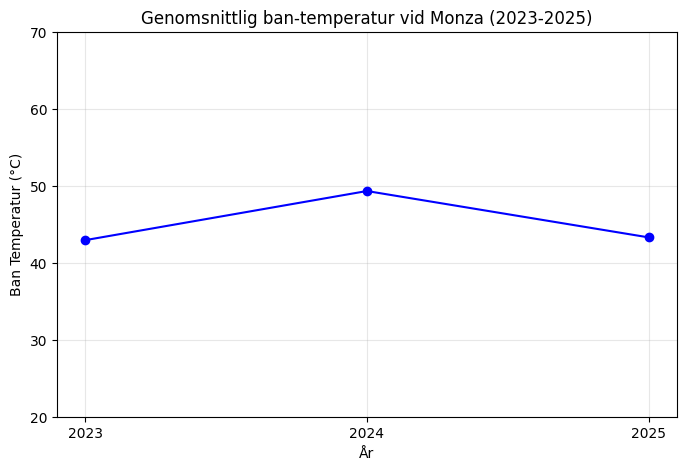

In [22]:
race_temperature_3_years = weather_df[
    (weather_df['session_name'] == 'Race') &
    (weather_df['year'].isin([2023, 2024, 2025]))
]

avg_track_temperature_monza = race_temperature_3_years.groupby('year')['track_temperature'].mean()

fig, ax = plt.subplots(figsize=(8, 5))

avg_track_temperature_monza.plot(kind='line', color='blue', marker='o', ax=ax)

ax.set_title('Genomsnittlig ban-temperatur vid Monza (2023-2025)')
ax.set_xlabel('År')
ax.set_ylabel('Ban Temperatur (°C)')
ax.set_ylim(20, 70)
ax.set_xticks([2023, 2024, 2025])


plt.grid(True, alpha=0.3)

plt.show()

In [ ]:
# Find out average rainfall on monza during all sessions in 2023, 2024, and 2025
rainfall_monza = weather_df[weather_df['year'].isin([2023, 2024, 2025])]

avg_rainfall_monza = rainfall_monza.groupby(['year', 'session_name'])['rainfall'].mean().reset_index()

print(avg_rainfall_monza)

# Tydligen inte regnat här på flera år så lite svårt att göra en graf etc. 

    year session_name  rainfall
0   2023   Practice 1       0.0
1   2023   Practice 2       0.0
2   2023   Practice 3       0.0
3   2023   Qualifying       0.0
4   2023         Race       0.0
5   2024   Practice 1       0.0
6   2024   Practice 2       0.0
7   2024   Practice 3       0.0
8   2024   Qualifying       0.0
9   2024         Race       0.0
10  2025   Practice 1       0.0
11  2025   Practice 2       0.0
12  2025   Practice 3       0.0
13  2025   Qualifying       0.0
14  2025         Race       0.0


### Vind riktning från Monza Race 2023-2025

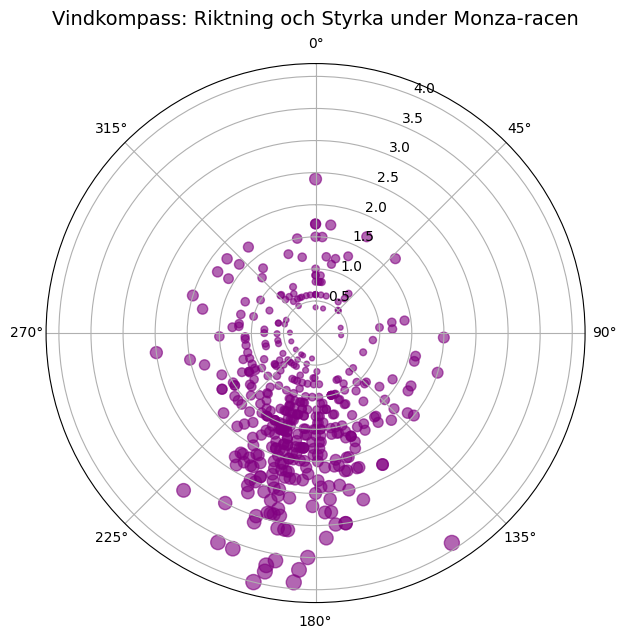

In [24]:

race_wind_monza = weather_df[(weather_df['session_name'] == 'Race')] 

#https://matplotlib.org/stable/gallery/pie_and_polar_charts/polar_demo.html
angles_rad = np.radians(race_wind_monza['wind_direction'])

# bygga en rund graf, "polar"
fig, ax = plt.subplots(figsize=(7, 7), subplot_kw={'projection': 'polar'})

# Sätt norr (0 grader) högst upp och vinklarna går medurs
ax.set_theta_zero_location("N")
ax.set_theta_direction(-1) 

# Scatter värden: Ju starkare wind_speed desto större prickar
scatter = ax.scatter(angles_rad, race_wind_monza['wind_speed'], alpha=0.6, color='purple', s=race_wind_monza['wind_speed']*30)

ax.set_title('Vindkompass: Riktning och Styrka under Monza-racen', va='bottom', fontsize=14)

plt.show()

## Clean Weather file more

In [ ]:
weather_df['date'] = pd.to_datetime(weather_df['date'])

if 'meeting_key_1' in weather_df.columns:
    weather_df = weather_df.drop(columns=['meeting_key_1'])

# Berätta för Pandas vilka kolumner som är Text/Kategorier och vilka som är Siffror
categorical_cols = ['session_key', 'session_type', 'session_name', 'year', 'circuit_short_name']
numerical_cols = ['pressure', 'track_temperature', 'rainfall', 'wind_speed', 'wind_direction', 'humidity', 'air_temperature']

# Ändra till 5 minuter mellanrum ('5min')
clean_weather = (
    weather_df.set_index('date')
    .groupby(categorical_cols)
    .resample('5min')[numerical_cols]
    .mean()
    .dropna()
    .reset_index()
)

# Avrunda decimalerna.
clean_weather = clean_weather.round({
    'track_temperature': 1,
    'air_temperature': 1,
    'wind_speed': 1,
    'pressure': 1,
    'humidity': 1,
    'wind_direction': 0  
})

# Se resultatet
print(len(clean_weather))
print(clean_weather)

299
     session_key session_type session_name  year circuit_short_name  \
0           9150     Practice   Practice 1  2023              Monza   
1           9150     Practice   Practice 1  2023              Monza   
2           9150     Practice   Practice 1  2023              Monza   
3           9150     Practice   Practice 1  2023              Monza   
4           9150     Practice   Practice 1  2023              Monza   
..           ...          ...          ...   ...                ...   
294         9912         Race         Race  2025              Monza   
295         9912         Race         Race  2025              Monza   
296         9912         Race         Race  2025              Monza   
297         9912         Race         Race  2025              Monza   
298         9912         Race         Race  2025              Monza   

                         date  pressure  track_temperature  rainfall  \
0   2023-09-01 11:15:00+00:00     997.7               40.7       0.0   

### Save csv files

In [26]:
clean_weather.to_csv('../data/csv/clean_weather_data.csv', index=False)
sessions_df.to_csv('../data/csv/sessions_data.csv', index=False)

## Drivers Checks

In [27]:
rows_of_drivers = len(drivers_df)
print(f"Number of rows in drivers_df: {rows_of_drivers}")


Number of rows in drivers_df: 300


In [28]:
# Save drivers_df to csv
drivers_df.to_csv('../data/csv/drivers_data.csv', index=False)

In [29]:
sessions_df = pd.read_csv('../data/csv/sessions_data.csv')

In [30]:
session_result_df.to_csv('../data/csv/session_result_data.csv', index=False)

In [31]:
meetings_df.to_csv('../data/csv/meetings_data.csv', index=False)

In [32]:
conn = duckdb.connect("../f1_data.duckdb")

sessions = """
    SELECT
        *
    FROM sessions_data
    ORDER BY year ASC
"""

sessions_df = conn.execute(sessions).df()


conn.close()

sessions_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 364 entries, 0 to 363
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   session_key         364 non-null    int64  
 1   session_type        364 non-null    str    
 2   session_name        364 non-null    str    
 3   date_start          364 non-null    str    
 4   date_end            364 non-null    str    
 5   meeting_key         364 non-null    int64  
 6   circuit_key         364 non-null    int64  
 7   circuit_short_name  364 non-null    str    
 8   country_key         364 non-null    int64  
 9   country_code        364 non-null    str    
 10  country_name        364 non-null    str    
 11  location            364 non-null    str    
 12  gmt_offset          364 non-null    str    
 13  year                364 non-null    int64  
 14  is_cancelled        364 non-null    bool   
 15  session_order       364 non-null    float64
dtypes: bool(1), float64

In [33]:
sessions_df.to_csv('../data/csv/sessions_data.csv', index=False)

### Extra Matplotlib graf

In [34]:
all_weather_df.head(10)

NameError: name 'all_weather_df' is not defined